In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv('Video_Games.csv')
df.head()

,index,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
#get the shape of the datafram (rows, columns)
df.shape

(16928, 17)

In [4]:
#get information on the dataset: missing values , type of columns ...
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16928 entries, 0 to 16927
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            16928 non-null  int64  
 1   Name             16926 non-null  object 
 2   Platform         16928 non-null  object 
 3   Year_of_Release  16655 non-null  float64
 4   Genre            16926 non-null  object 
 5   Publisher        16873 non-null  object 
 6   NA_Sales         16928 non-null  float64
 7   EU_Sales         16928 non-null  float64
 8   JP_Sales         16928 non-null  float64
 9   Other_Sales      16928 non-null  float64
 10  Global_Sales     16928 non-null  float64
 11  Critic_Score     8260 non-null   float64
 12  Critic_Count     8260 non-null   float64
 13  User_Score       10159 non-null  object 
 14  User_Count       7718 non-null   float64
 15  Developer        10240 non-null  object 
 16  Rating           10092 non-null  object 
dtypes: float64(9

In [5]:
# sum of all the null values
df.isnull().sum()

index                 0
Name                  2
Platform              0
Year_of_Release     273
Genre                 2
Publisher            55
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8668
Critic_Count       8668
User_Score         6769
User_Count         9210
Developer          6688
Rating             6836
dtype: int64

In [6]:
#HOW MANY GAMES HAVE BOTH CRITIC AND USER SCORES AVAILABLE ?
games_with_scores = df[['Critic_Score', 'User_Score']].dropna()
games_with_scores_count = games_with_scores.shape[0]
games_with_scores_count

df.describe()

,index,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,16928.000000,16655.00000,16928.000000,16928.000000,16928.000000,16928.000000,16928.000000,8260.000000,8260.000000,7718.000000
mean,8463.500000,2006.48532,0.266390,0.146850,0.078170,0.047861,0.539520,69.037893,26.428692,163.269629
std,4886.837014,5.88289,0.814326,0.504585,0.308756,0.186675,1.550545,13.943198,18.989929,562.786746
min,0.000000,1980.00000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,4.000000
25%,4231.750000,2003.00000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,10.000000
50%,8463.500000,2007.00000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,22.000000,25.000000
75%,12695.250000,2010.00000,0.240000,0.110000,0.040000,0.040000,0.490000,79.000000,36.000000,82.000000
max,16927.000000,2020.00000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,10665.000000


<function matplotlib.pyplot.show(close=None, block=None)>

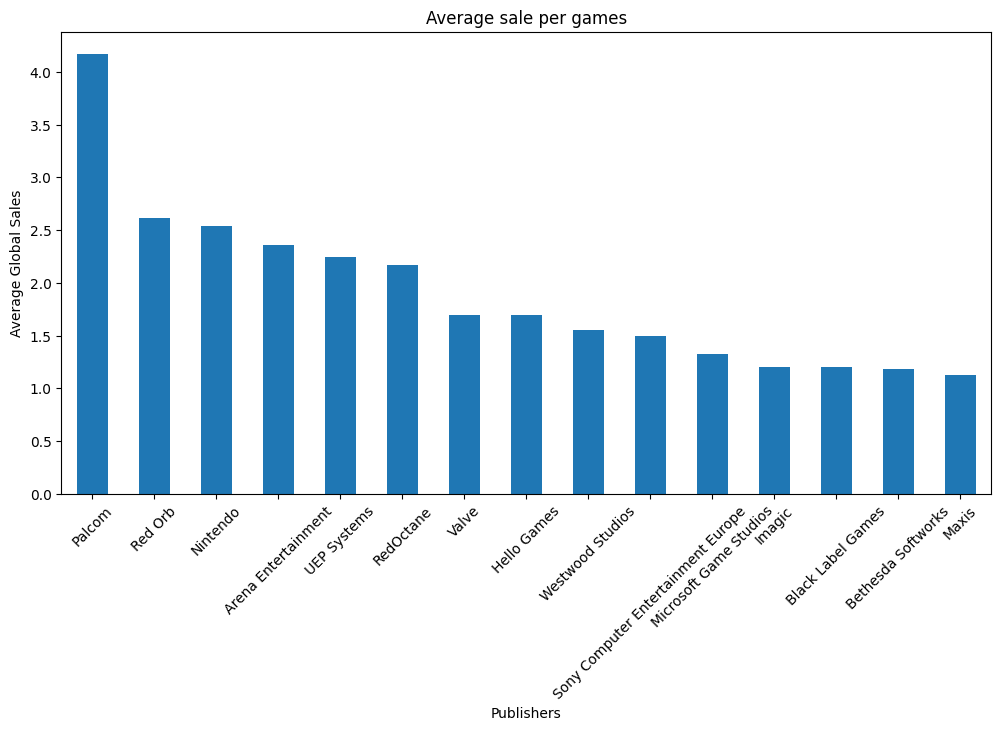

In [7]:
#Which publisher has the highest average sale per games?

average_sale_per_games = df.groupby('Publisher')['Global_Sales'].mean().sort_values(ascending=False)


plt.figure(figsize=(12,6))
average_sale_per_games.head(15).plot(kind="bar")
plt.title("Average sale per games")
plt.xlabel('Publishers')
plt.ylabel('Average Global Sales')
plt.xticks(rotation = 45)
plt.show

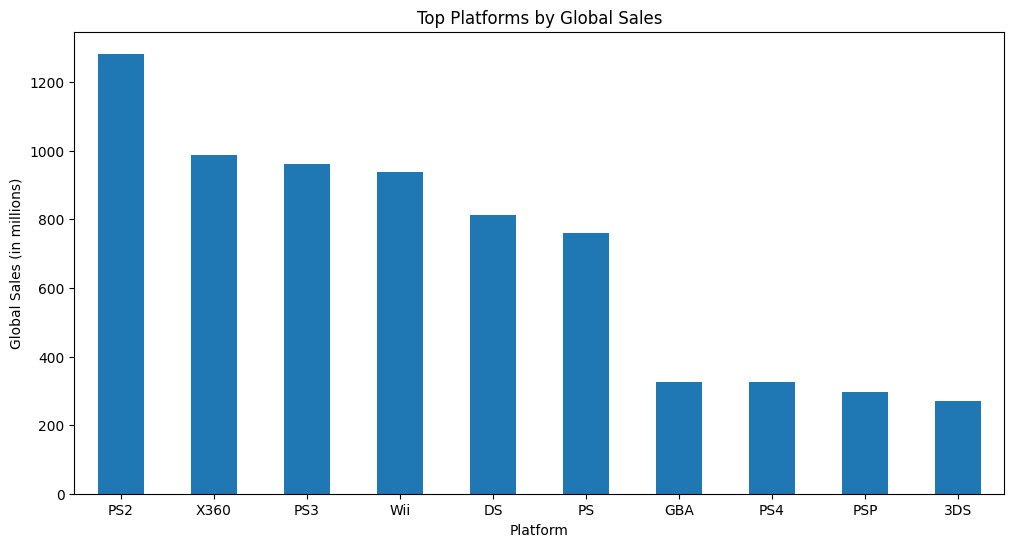

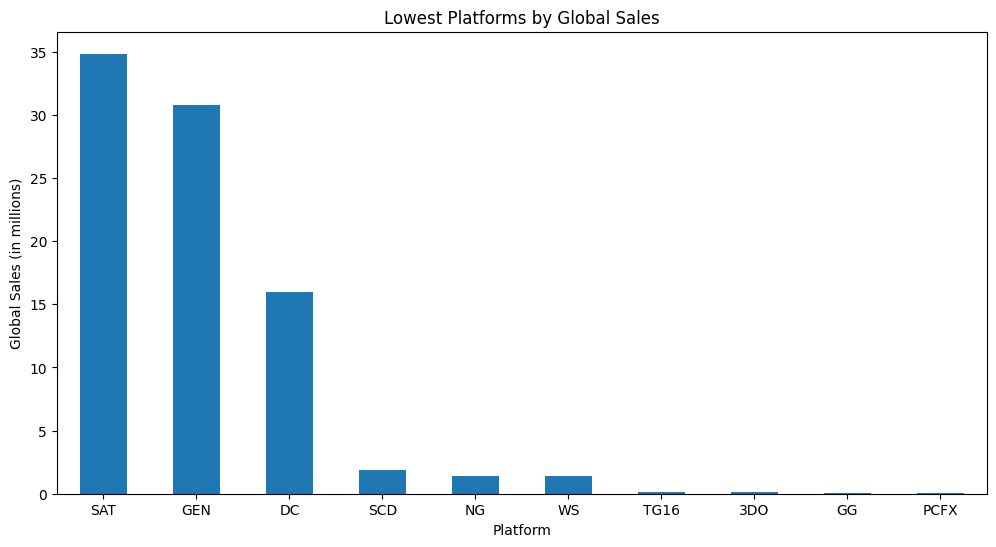

(Platform        0
 Global_Sales    0
 dtype: int64,
 Platform
 PS2     1283.08
 X360     988.36
 PS3      962.71
 Wii      937.27
 DS       813.86
 PS       759.88
 GBA      327.11
 PS4      324.48
 PSP      298.02
 3DS      271.21
 Name: Global_Sales, dtype: float64)

In [8]:
#WHAT PLATFORMS HAVE THE HIGHEST GLOBAL SALES?
missing_values_platforms = df[['Platform', 'Global_Sales']].isnull().sum()

platform_sales = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending = False)

#difplay the top platforms by global sales
top_platforms = platform_sales.head(10)


#visualisation
plt.figure(figsize=(12,6))
top_platforms.plot(kind = 'bar')
plt.title('Top Platforms by Global Sales')
plt.xlabel('Platform')
plt.ylabel('Global Sales (in millions)')
plt.xticks(rotation = 0)
plt.show()

bottom_platforms = platform_sales.tail(10)
plt.figure(figsize=(12,6))
bottom_platforms.plot(kind = 'bar')
plt.title('Lowest Platforms by Global Sales')
plt.xlabel('Platform')
plt.ylabel('Global Sales (in millions)')
plt.xticks(rotation = 0)
plt.show()


missing_values_platforms, top_platforms

/var/folders/ky/wtg1vw412sz5kfbftp83kvn40000gn/T/ipykernel_36724/3840001893.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(best_selling_games, labels = best_selling_games.index.astype(int))


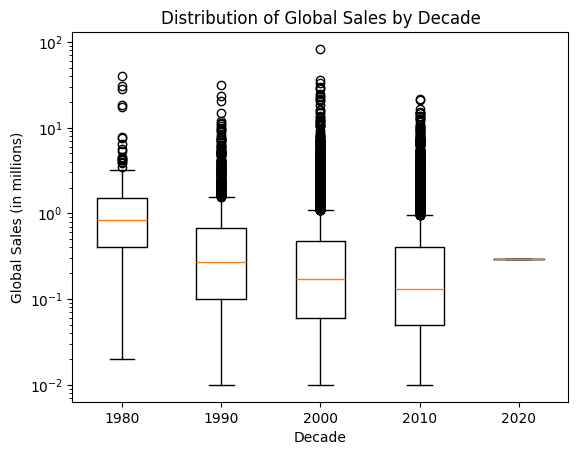

In [9]:
#What decade produced the best selling games?
df['Decade'] = (df['Year_of_Release']//10)*10
best_selling_games = df.groupby("Decade")['Global_Sales'].apply(list)

plt.boxplot(best_selling_games, labels = best_selling_games.index.astype(int))
plt.yscale('log')
plt.xlabel('Decade')
plt.ylabel('Global Sales (in millions)')
plt.title('Distribution of Global Sales by Decade')
plt.show()

In [10]:
df[df['Decade'] == 2020]['Global_Sales']

5936    0.29
Name: Global_Sales, dtype: float64

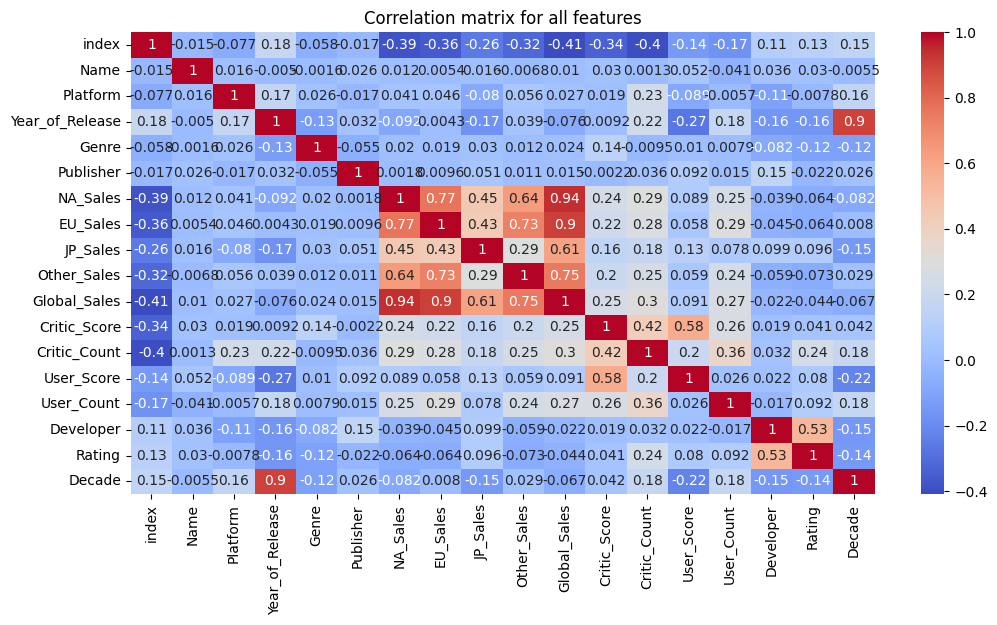

In [11]:
#WHAT FEATURES CORRELATE WITH HIGH USER SCORE?
df['User_Score'] = pd.to_numeric(df['User_Score'], errors= 'coerce')
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = df[column].astype('category')
        df[column] = le.fit_transform(df[column].cat.codes.replace(-1,np.nan))

#calculate the correlation matrix
correcation_matrix = df.corr()


#visualisation 
plt.figure(figsize=(12,6))
sns.heatmap(correcation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation matrix for all features')
plt.show()

/var/folders/ky/wtg1vw412sz5kfbftp83kvn40000gn/T/ipykernel_36724/946266173.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  video_games_df["Year_of_Release"] = video_games_df['Year_of_Release'].astype(int)


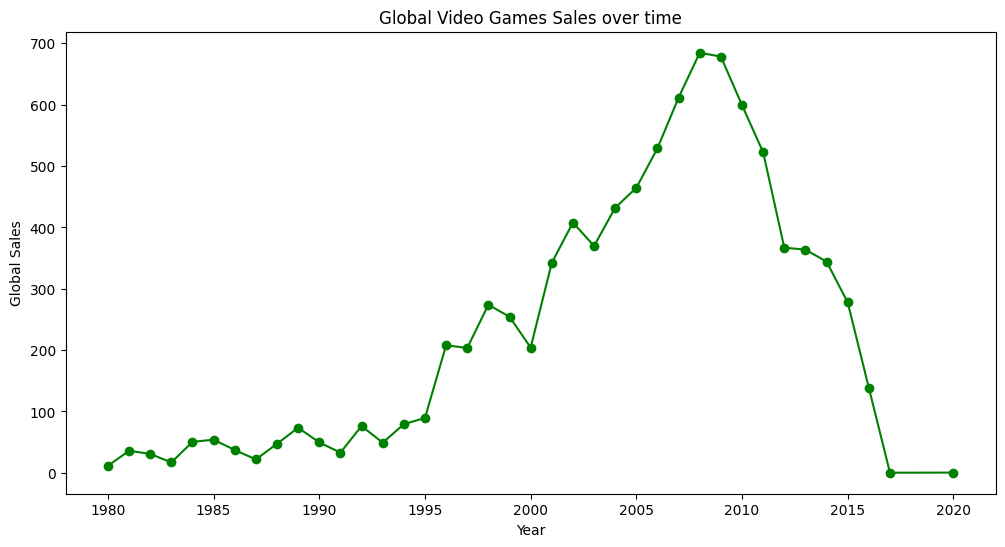

In [12]:
#EXAMINE HOW VIDEO GAMES HAVE CHANGED OVER THE YEARS.
video_games_df = df.dropna(subset=['Year_of_Release'])

video_games_df["Year_of_Release"] = video_games_df['Year_of_Release'].astype(int)
yearly_sales = video_games_df.groupby('Year_of_Release')["Global_Sales"].sum()

#ploting
plt.figure(figsize=(12,6))
yearly_sales.plot(kind = 'line', color = 'green', marker = 'o')
plt.title('Global Video Games Sales over time')
plt.xlabel('Year')
plt.ylabel('Global Sales')
plt.show()

<Figure size 1800x600 with 0 Axes>

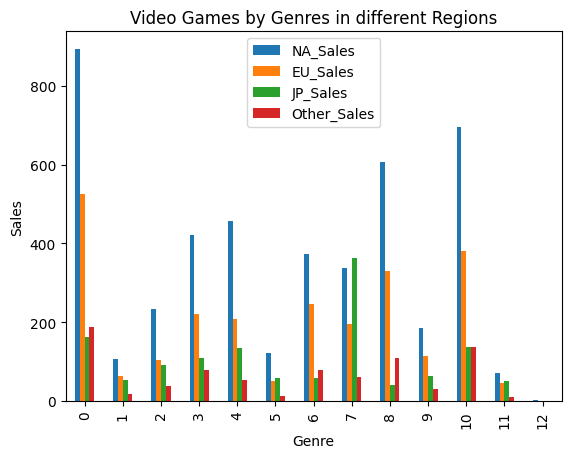

In [13]:
#COMPARE THE POPULARITY OF GENRES ACROSS DIFFERENT REGIONS.
region_genre_sales = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales' , 'Other_Sales']].sum()

#ploting
plt.figure(figsize=(18,6))
region_genre_sales.plot(kind = 'bar')
plt.title('Video Games by Genres in different Regions')
plt.xlabel('Genre')
plt.ylabel('Sales')
plt.show()
